In [4]:
import numpy as np

# A tiny made-up dataset: hours studied -> exam score
hours_studied   = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
observed_scores = np.array([52.0, 60.0, 67.0, 77.0, 84.0])

# Fit the simplest possible model: a straight line  score = slope*hours + intercept
slope, intercept = np.polyfit(hours_studied, observed_scores, deg=1)
predicted_scores = slope * hours_studied + intercept

In [5]:
np.abs(predicted_scores - observed_scores)

array([0.2, 0.1, 1. , 0.9, 0.2])

## Notes / Questions
- why is the residual == x? should'nt it be a small amount ?

### Part 1 — A problem we can fully see

So we use 1-D regression: learn a wiggly curve `y = f(x)` from input `x`. A neural
network fitting a curve is the simplest setting where *depth* matters, with nothing
else (images, data loaders, augmentation) to distract us.

In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility: fix every random seed we touch.
RANDOM_SEED = 0
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("torch version:", torch.__version__)
print("running on   :", "cuda" if torch.cuda.is_available() else "cpu")

Matplotlib is building the font cache; this may take a moment.


torch version: 2.12.1
running on   : cpu


In [17]:
# synthetic dataset
dataset_size = 512

x = torch.linspace(-5.0, 5.0, dataset_size).unsqueeze(1)

y = torch.sin(3.0 * x) + 0.3 * torch.sin(9.0 * x) + 0.1 * x

x = ( x - x.mean())/x.std()

# we can do this to y: since this is a affine transformation so we can recover the results later. but it helps with the demo
y = (y-y.mean())/y.std()


In [18]:
x.shape, x.unsqueeze(1).shape

(torch.Size([512, 1]), torch.Size([512, 1, 1]))

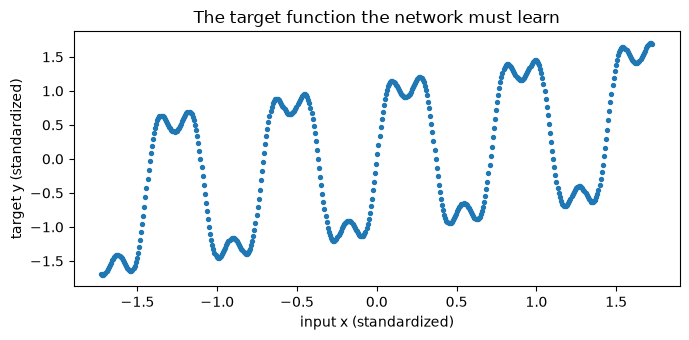

In [19]:
plt.figure(figsize=(7, 3.5))
plt.scatter(x.numpy(), y.numpy(), s=8)
plt.title("The target function the network must learn")
plt.xlabel("input x (standardized)")
plt.ylabel("target y (standardized)")
plt.tight_layout()
plt.show()

### Deeper network can always match a shallower one

By learning the identity function, deeper can always match a shallower one. Thus, a deeper network can represent a more complex set of functions.

In [23]:
class PlainNetwork(nn.Module):
    '''A plain feed-forward network: stack `depth` hidden layers, no shortcuts.'''

    def __init__(self, depth, width=64):
        super().__init__()

        list_of_layers = []

        # First layer maps the 1-D input up to `width` features.
        list_of_layers.append(nn.Linear(1, width))
        #list_of_layers.append(nn.Tanh())
        list_of_layers.append(nn.ReLU())


        # Then `depth` hidden layers, each width -> width followed by an activation.
        for hidden_layer_index in range(depth):
            list_of_layers.append(nn.Linear(width, width))
            #list_of_layers.append(nn.Tanh())
            list_of_layers.append(nn.ReLU())

        # Final layer maps the features back down to a single output number.
        list_of_layers.append(nn.Linear(width, 1))

        # nn.Sequential just calls each layer in order.
        self.stack_of_layers = nn.Sequential(*list_of_layers)

    def forward(self, x):
        return self.stack_of_layers(x)

    def numel(self):
        s = sum(p.numel()  for l in self.stack_of_layers for p in l.parameters())
        return s


# A small helper that trains any model on our dataset and returns the final
# TRAINING loss. We care about TRAINING loss specifically: if a deep network can't
# even fit the data it was trained on, that is NOT overfitting -- it is a failure
# to optimize.
def train_model_and_return_final_training_loss(model, number_of_epochs=1200, learning_rate=3e-3):
    optimizer    = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_function = nn.MSELoss()

    for epoch in range(number_of_epochs):
        optimizer.zero_grad()
        predictions = model(inputs_x)
        loss        = loss_function(predictions, targets_y)
        loss.backward()
        optimizer.step()

    return loss.item()

inputs_x = x
targets_y = y

In [24]:
# Sanity check: a SHALLOW plain network should fit this curve easily.
loss_curve=[]
for depth in range(2, 40):
    torch.manual_seed(RANDOM_SEED)
    shallow_plain_network = PlainNetwork(depth=depth)
    final_loss = train_model_and_return_final_training_loss(shallow_plain_network)
    print(f" plain network (depth={depth}) final training MSE: {final_loss:.4f}")
    loss_curve.append(final_loss)


with torch.no_grad():
    shallow_predictions = shallow_plain_network(inputs_x)


shallow plain network (depth=2) final training MSE: 0.0290
shallow plain network (depth=3) final training MSE: 0.0063
shallow plain network (depth=4) final training MSE: 0.0052
shallow plain network (depth=5) final training MSE: 0.0043
shallow plain network (depth=6) final training MSE: 0.0142
shallow plain network (depth=7) final training MSE: 0.0072
shallow plain network (depth=8) final training MSE: 0.0095
shallow plain network (depth=9) final training MSE: 0.0014
shallow plain network (depth=10) final training MSE: 0.0038
shallow plain network (depth=11) final training MSE: 0.0012
shallow plain network (depth=12) final training MSE: 0.0018
shallow plain network (depth=13) final training MSE: 0.0047
shallow plain network (depth=14) final training MSE: 0.0096
shallow plain network (depth=15) final training MSE: 0.0101
shallow plain network (depth=16) final training MSE: 0.0069
shallow plain network (depth=17) final training MSE: 0.0039
shallow plain network (depth=18) final training 

In [30]:
# Sanity check: a SHALLOW plain network should fit this curve easily.
loss_curve=[]
for depth in range(23, 40):
    torch.manual_seed(RANDOM_SEED)
    shallow_plain_network = PlainNetwork(depth=depth)
    final_loss = train_model_and_return_final_training_loss(shallow_plain_network, number_of_epochs=4800)
    print(f" plain network (depth={depth}) final training MSE: {final_loss:.4f}")
    loss_curve.append(final_loss)


with torch.no_grad():
    shallow_predictions = shallow_plain_network(inputs_x)

 plain network (depth=23) final training MSE: 0.0039
 plain network (depth=24) final training MSE: 0.9980
 plain network (depth=25) final training MSE: 0.9980
 plain network (depth=26) final training MSE: 0.9980
 plain network (depth=27) final training MSE: 0.9980
 plain network (depth=28) final training MSE: 0.9980
 plain network (depth=29) final training MSE: 0.9980
 plain network (depth=30) final training MSE: 0.9980
 plain network (depth=31) final training MSE: 0.9980
 plain network (depth=32) final training MSE: 0.9980
 plain network (depth=33) final training MSE: 0.9980


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(7, 3.5))
plt.scatter(list(range(2, 24)), final_loss, s=8, label="target")
plt.plot(inputs_x.numpy(), shallow_predictions.numpy(), color="red", label="shallow net fit")
#plt.scatter(inputs_x.numpy(), shallow_predictions.numpy(), color="purple", label="shallow net fit")
plt.title("A shallow plain network fits the curve just fine")
plt.legend(); plt.tight_layout(); plt.show()

In [1]:
plt.figure(figsize=(7, 3.5))
plt.scatter(inputs_x.numpy(), targets_y.numpy(), s=8, label="target")
plt.plot(inputs_x.numpy(), shallow_predictions.numpy(), color="red", label="shallow net fit")
#plt.scatter(inputs_x.numpy(), shallow_predictions.numpy(), color="purple", label="shallow net fit")
plt.title("A shallow plain network fits the curve just fine")
plt.legend(); plt.tight_layout(); plt.show()

NameError: name 'plt' is not defined

In [43]:
def add_plot(t, legend, legends_list):
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends_list.append(f"{legend}-{t.shape}")

In [44]:
# Run a forward + backward pass (no step) and compute the gradients distribution at each layer.
def grads_at_each_layer(model):
    model.zero_grad()
    loss_function = nn.MSELoss()
    outputs = model(inputs_x)
    loss = loss_function(outputs, targets_y)
    loss.backward()
    

In [55]:
grads_at_each_layer(shallow_plain_network)

layer_weight_gradients = []
layer_bias_gradients = []

model = shallow_plain_network

# Iterate through each layer and its corresponding grad if it has parameters
for name, parameter in model.named_parameters():
    print(name, parameter.shape)
    if 'weight' in name:
        layer_weight_gradients.append(parameter.grad.view(-1))
    if 'bias' in name:
        layer_bias_gradients.append(parameter.grad.view(-1))


stack_of_layers.0.weight torch.Size([64, 1])
stack_of_layers.0.bias torch.Size([64])
stack_of_layers.2.weight torch.Size([64, 64])
stack_of_layers.2.bias torch.Size([64])
stack_of_layers.4.weight torch.Size([64, 64])
stack_of_layers.4.bias torch.Size([64])
stack_of_layers.6.weight torch.Size([64, 64])
stack_of_layers.6.bias torch.Size([64])
stack_of_layers.8.weight torch.Size([64, 64])
stack_of_layers.8.bias torch.Size([64])
stack_of_layers.10.weight torch.Size([64, 64])
stack_of_layers.10.bias torch.Size([64])
stack_of_layers.12.weight torch.Size([64, 64])
stack_of_layers.12.bias torch.Size([64])
stack_of_layers.14.weight torch.Size([64, 64])
stack_of_layers.14.bias torch.Size([64])
stack_of_layers.16.weight torch.Size([64, 64])
stack_of_layers.16.bias torch.Size([64])
stack_of_layers.18.weight torch.Size([64, 64])
stack_of_layers.18.bias torch.Size([64])
stack_of_layers.20.weight torch.Size([64, 64])
stack_of_layers.20.bias torch.Size([64])
stack_of_layers.22.weight torch.Size([64, 6

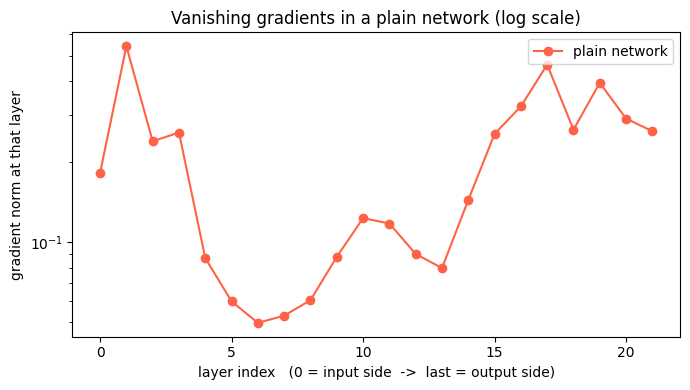

output-side gradient is ~1x larger than input-side gradient
=> the early layers receive almost no signal, so they barely learn.


In [56]:

def gradient_norm_at_each_layer(model):
    '''Run one forward+backward pass and return the gradient norm of each weight,
    ordered from the FIRST (input-side) layer to the LAST (output-side) layer.'''
    model.zero_grad()
    loss = nn.MSELoss()(model(inputs_x), targets_y)
    loss.backward()
    norms = [parameter.grad.norm().item()
             for name, parameter in model.named_parameters()
             if "weight" in name]
    return norms

torch.manual_seed(1)

plain_gradient_norms = gradient_norm_at_each_layer(shallow_plain_network)

plt.figure(figsize=(7, 4))
plt.semilogy(range(len(plain_gradient_norms)), plain_gradient_norms,
             marker="o", color="tomato", label="plain network")
plt.title("Vanishing gradients in a plain network (log scale)")
plt.xlabel("layer index   (0 = input side  ->  last = output side)")
plt.ylabel("gradient norm at that layer")
plt.legend(); plt.tight_layout(); plt.show()

ratio = plain_gradient_norms[-1] / plain_gradient_norms[0]
print(f"output-side gradient is ~{ratio:,.0f}x larger than input-side gradient")
print("=> the early layers receive almost no signal, so they barely learn.")

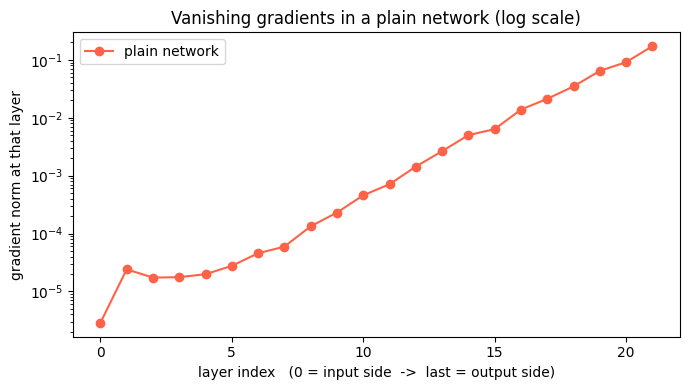

output-side gradient is ~60,297x larger than input-side gradient
=> the early layers receive almost no signal, so they barely learn.


In [50]:
plain_net_for_gradients = PlainNetwork(depth=20)
plain_gradient_norms = gradient_norm_at_each_layer(plain_net_for_gradients)

plt.figure(figsize=(7, 4))
plt.semilogy(range(len(plain_gradient_norms)), plain_gradient_norms,
             marker="o", color="tomato", label="plain network")
plt.title("Vanishing gradients in a plain network (log scale)")
plt.xlabel("layer index   (0 = input side  ->  last = output side)")
plt.ylabel("gradient norm at that layer")
plt.legend(); plt.tight_layout(); plt.show()

ratio = plain_gradient_norms[-1] / plain_gradient_norms[0]
print(f"output-side gradient is ~{ratio:,.0f}x larger than input-side gradient")
print("=> the early layers receive almost no signal, so they barely learn.")